# Page Categorization
Manual tagging pass: assign a structural category (text-only, chapter start, illustration, mixed, unknown) to each processed page, using `Category_Registry`. This is the human-judgment step feeding the category-level comparison in `06_category_signature_comparison.ipynb`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from xrf.config import Xrf_Comparison_Config
from xrf.comparison.category_registry import Category_Registry

comparison_config = Xrf_Comparison_Config()
print("Allowed categories:", comparison_config.Allowed_Categories)

Allowed categories: ['text_only', 'chapter_start', 'illustration', 'mixed', 'unknown']


In [2]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data" / "xrf"
OUTPUT_DATA_DIR = DATA_DIR / "output"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

## List processed pages
Scan `data/xrf/output/processed/` for `page_*_meta.json` and show which pages are already tagged, grouped by category.

In [3]:
Meta_Paths = sorted(PROCESSED_DATA_DIR.glob("page_*_meta.json"))
print(f"Found {len(Meta_Paths)} processed page(s):")
for Meta_Path in Meta_Paths:
    Page_Id = Meta_Path.stem.replace("_meta", "")
    Existing_Category = Category_Registry.Load_Page_Category(Meta_Path)
    print(f"  {Page_Id}: {Existing_Category if Existing_Category is not None else 'untagged'}")

Found 1 processed page(s):
  page_001: untagged


## Tag each untagged page
For every untagged page, display the reconstructed `class_map` for visual context, then prompt for a category restricted to `Xrf_Comparison_Config.Allowed_Categories`. Re-run this cell as many times as needed across a tagging session — already-tagged pages are skipped.

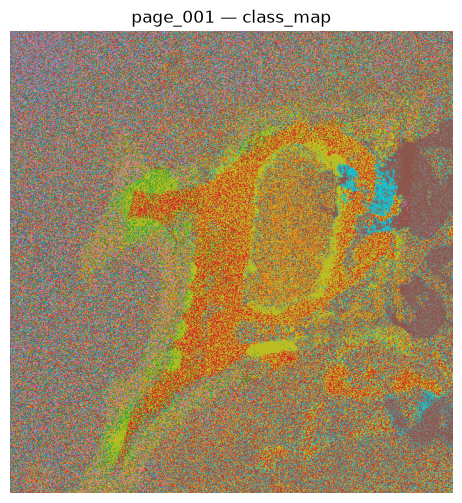

[Xrf_Loader] updated metadata fields ['structural_category', 'structural_category_source', 'structural_category_secondary', 'structural_category_notes'] in c:\Users\gabri\Documento\Mitacs\research_ct\data\xrf\output\processed\page_001_meta.json
[Category_Registry] tagged page_001 as text_only (manual)


In [4]:
for Meta_Path in Meta_Paths:
    Page_Id = Meta_Path.stem.replace("_meta", "")

    if Category_Registry.Load_Page_Category(Meta_Path) is not None:
        continue

    Class_Map_Path = PROCESSED_DATA_DIR / f"{Page_Id}_class_map.npy"
    if Class_Map_Path.exists():
        Class_Map = np.load(Class_Map_Path)
        plt.figure(figsize=(6, 6))
        plt.imshow(Class_Map, cmap="tab10")
        plt.title(f"{Page_Id} — class_map")
        plt.axis("off")
        plt.show()
    else:
        print(f"No class_map found for {Page_Id}, tagging from context/metadata only.")

    Category_Input = input(
        f"Category for {Page_Id} {comparison_config.Allowed_Categories}: "
    ).strip()

    try:
        Category_Registry.Write_Page_Category(
            Meta_Path,
            Category_Input,
            comparison_config,
            Tag_Source="manual",
        )
    except ValueError as Error:
        print(f"Skipped {Page_Id}: {Error}")

## Tagging summary
Show pages grouped by category and flag any category still under `Min_Pages_Per_Category`.

In [5]:
Tagged_Pages = Category_Registry.List_Tagged_Pages(PROCESSED_DATA_DIR, comparison_config)

for Category, Page_Ids in Tagged_Pages.items():
    Flag = (
        " (low-confidence: below Min_Pages_Per_Category)"
        if Category != "untagged" and len(Page_Ids) < comparison_config.Min_Pages_Per_Category
        else ""
    )
    print(f"{Category}: {len(Page_Ids)} page(s){Flag} -> {Page_Ids}")

text_only: 1 page(s) (low-confidence: below Min_Pages_Per_Category) -> ['page_001']
